<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
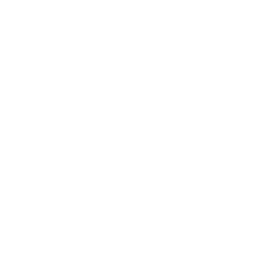
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Παρακολούθηση Διεργασίας Έλασης Χαλυβουργείου</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Πολυμεταβλητός στατιστικός έλεγχος διεργασίας (SPC) για το πάχος και την ποιότητα επιφάνειας θερμής έλασης λωρίδας &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Ένα εργοστάσιο θερμής έλασης λωρίδας ελάσσει χαλύβδινες πλάκες σε λεπτό
ρόλο. Οκτώ συσχετισμένα σήματα διεργασίας (πάχη, δύναμη έλασης, διάκενο
κυλίνδρων, ρεύμα κινητήρα, θερμοκρασία εξόδου) κινούνται μαζί όταν η
γραμμή είναι υγιής, οπότε η παρακολούθηση ενός γραφήματος τη φορά χάνει
τις κοινές μεταβολές που έχουν σημασία. Αυτό το παράδειγμα χτίζει μια
πολυμεταβλητή γραμμή αναφοράς με την **PROC MVPMODEL** και στη συνέχεια
διοχετεύει 100 ρόλους παραγωγής μέσω της **PROC MVPMONITOR**, η οποία
βαθμολογεί κάθε ρόλο με ένα ενιαίο στατιστικό *T*&sup2; του Hotelling και
το συγκρίνει με ένα όριο ελέγχου.

Έναντι ενός ορίου εντός ελέγχου *T*&sup2; = **17,13** (&alpha; = 0,05),
**4 από τους 100 ρόλους** σηματοδοτούν κατάσταση εκτός ελέγχου — οι ρόλοι
**91, 92, 94 και 95**, ακριβώς στο παράθυρο όπου εισήχθη μια έκρηξη
κρότου (chatter) του οπίσθιου κυλίνδρου. Το μέγιστο *T*&sup2; φτάνει το
**21,91** στον ρόλο 95, περίπου **1,3&times;** το όριο. Η σταδιακή
αύξηση φθοράς κυλίνδρου στους μεταγενέστερους ρόλους ανεβάζει τη
γραμμή αναφοράς *T*&sup2;, αλλά παραμένει κάτω από το όριο μέχρι το
συμβάν κρότου, οπότε το γράφημα διαχωρίζει καθαρά την αργή μετατόπιση
από το οξύ σφάλμα που χρειάζεται άμεση προσοχή.


## Πηγές Δεδομένων

- **mill_baseline** &mdash; 50 ρόλοι που ελάσθηκαν σε ένα γνωστό καλό
  διάστημα της εκστρατείας· χρησιμοποιούνται για την προσαρμογή του
  πολυμεταβλητού (PCA) μοντέλου αναφοράς.
- **mill_stream** &mdash; 100 ρόλοι από τη ζωντανή γραμμή. Οι ρόλοι
  1&ndash;55 λειτουργούν εντός ελέγχου· η φθορά κυλίνδρου αναπτύσσεται
  σταδιακά στους ρόλους 56&ndash;100· μια έκρηξη κρότου οπίσθιου
  κυλίνδρου χτυπά τους ρόλους 91&ndash;95.
- **Μεταβλητές διεργασίας** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Το περιβάλλον εκτελείται χωρίς άδεια χρήσης, οπότε τα σύνολα δεδομένων
> περιορίζονται σε 100 παρατηρήσεις. Το σενάριο έχει διαστασιολογηθεί
> για αυτό το όριο: η διαταραχή τοποθετείται αργά σε μια ροή 100 ρόλων
> αντί στον ρόλο 2.800 από 5.000.


---


### Βήμα 1 &mdash; Δημιουργία του πολυμεταβλητού μοντέλου αναφοράς

Η `PROC MVPMODEL` εκτελεί ανάλυση κύριων συνιστωσών των έξι μεταβλητών
διεργασίας στη γραμμή αναφοράς εντός ελέγχου και γράφει τα φορτία, τις
ιδιοτιμές και το κεντράρισμα/κλιμάκωση στο `mill_model`. Διατηρούνται
τρεις συνιστώσες. Αυτό το μοντέλο ορίζει το πώς μοιάζει το "φυσιολογικό"
ως μία ενιαία πολυμεταβλητή περιοχή αντί για έξι ανεξάρτητα εύρη.


In [1]:
ΔΕΔΟΜΕΝΑ mill_baseline;
  CALL streaminit(66);
  ΕΠΑΝΑΛΗΨΗ coil_id = 1 ΕΩΣ 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    ΕΞΟΔΟΣ;
  ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ mvpmodel ΔΕΔΟΜΕΝΑ=mill_baseline outmodel=mill_model;
  ΜΕΤΑΒΛΗΤΗ entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
ΕΚΤΕΛΕΣΗ;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---


### Βήμα 2 &mdash; Ροή των ρόλων παραγωγής και βαθμολόγησή τους

Η `PROC MVPMONITOR` προβάλλει καθέναν από τους 100 ρόλους παραγωγής στο
αποθηκευμένο μοντέλο και υπολογίζει το *T*&sup2; του Hotelling. Η
διαδικασία προκύπτει το όριο ελέγχου από τις διαστάσεις του μοντέλου και
το προεπιλεγμένο &alpha; = 0,05, και στη συνέχεια σημαίνει κάθε ρόλο του
οποίου το *T*&sup2; το υπερβαίνει. Τα αποτελέσματα, συμπεριλαμβανομένων
των στηλών `_TSQUARED`, `_LIMIT` και `_SIGNAL`, γράφονται στο
`mill_scores` με κλειδί το `coil_id`.


In [2]:
ΔΕΔΟΜΕΝΑ mill_stream;
  CALL streaminit(42);
  ΕΠΑΝΑΛΗΨΗ coil_id = 1 ΕΩΣ 100;
    /* roll wear ramps 0 -> 1 over coils 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* backup-roll chatter burst on coils 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    ΑΦΑΙΡΕΣΗ wear chatter;
    ΕΞΟΔΟΣ;
  ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ mvpmonitor ΔΕΔΟΜΕΝΑ=mill_stream ΜΟΝΤΕΛΟ=mill_model
                out=mill_scores;
  ΜΕΤΑΒΛΗΤΗ entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
ΕΚΤΕΛΕΣΗ;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Η σύνοψη της διαδικασίας αναφέρει το όριο ελέγχου και τον αριθμό
σημάτων. Παρακάτω, το τυπωμένο τμήμα γύρω από τη διαταραχή δείχνει ότι
οι ρόλοι αναφοράς παραμένουν σαφώς κάτω από το όριο, ενώ το παράθυρο
κρότου οδηγεί τέσσερις ρόλους πάνω από αυτό.


In [3]:
/* Επισήμανση ρόλων εκτός ελέγχου και καταγραφή του T2 συναγερμού για γράφημα */
ΔΕΔΟΜΕΝΑ mill_scores;
  ΟΡΙΣΜΟΣ mill_scores;
  ΕΑΝ _SIGNAL = 1 ΤΟΤΕ t2_alarm = _TSQUARED;
  ΑΛΛΙΩΣ t2_alarm = .;
  ΕΤΙΚΕΤΑ coil_id = "Αναγνωριστικό Ρόλου"
        entry_thickness = "Πάχος Εισόδου (mm)"
        exit_thickness = "Πάχος Εξόδου (mm)"
        rolling_force = "Δύναμη Έλασης (kN)"
        roll_gap = "Διάκενο Κυλίνδρων (mm)"
        motor_current = "Ρεύμα Κινητήρα (A)"
        exit_temp = "Θερμοκρασία Εξόδου (°C)"
        _TSQUARED = "Στατιστικό T2"
        _LIMIT = "Όριο Ελέγχου"
        _SIGNAL = "Σήμα Εκτός Ελέγχου"
        t2_alarm = "T2 Συναγερμού";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=mill_scores(firstobs=88 obs=96) noobs label;
  ΜΕΤΑΒΛΗΤΗ coil_id _TSQUARED _LIMIT _SIGNAL;
  TITLE 'Βαθμολογίες T2 στο παράθυρο κρότου (ρόλοι 88-96)';
ΕΚΤΕΛΕΣΗ;


                                    Βαθμολογίες T2 στο παράθυρο κρότου (ρόλοι 88-96)                                    

                  Αναγνωριστικό Ρόλου            Στατιστικό T2             Όριο Ελέγχου                  Σήμα Εκτός Ελέγχου
                                   88                 9.983151                17.133408                                   0
                                   89                 2.915646                17.133408                                   0
                                   90                  7.80613                17.133408                                   0
                                   91                18.813814                17.133408                                   1
                                   92                18.249361                17.133408                                   1
                                   93                16.638221                17.133408                                   0
          


NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---


### Βήμα 3 &mdash; Πολυμεταβλητό διάγραμμα ελέγχου

Το γράφημα υπερθέτει το ανά ρόλο *T*&sup2; έναντι του ορίου ελέγχου του.
Οι ρόλοι εκτός ελέγχου επισημαίνονται με κόκκινο· ο διακεκομμένος
κατακόρυφος δείκτης σημαίνει την έναρξη της έκρηξης κρότου. Η αργή
άνοδος προς τα δεξιά είναι η φθορά κυλίνδρου που ανεβάζει τη γραμμή
αναφοράς· τα τέσσερα κόκκινα σημεία είναι το οξύ σφάλμα κρότου.


                                    Βαθμολογίες T2 στο παράθυρο κρότου (ρόλοι 88-96)                                    




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


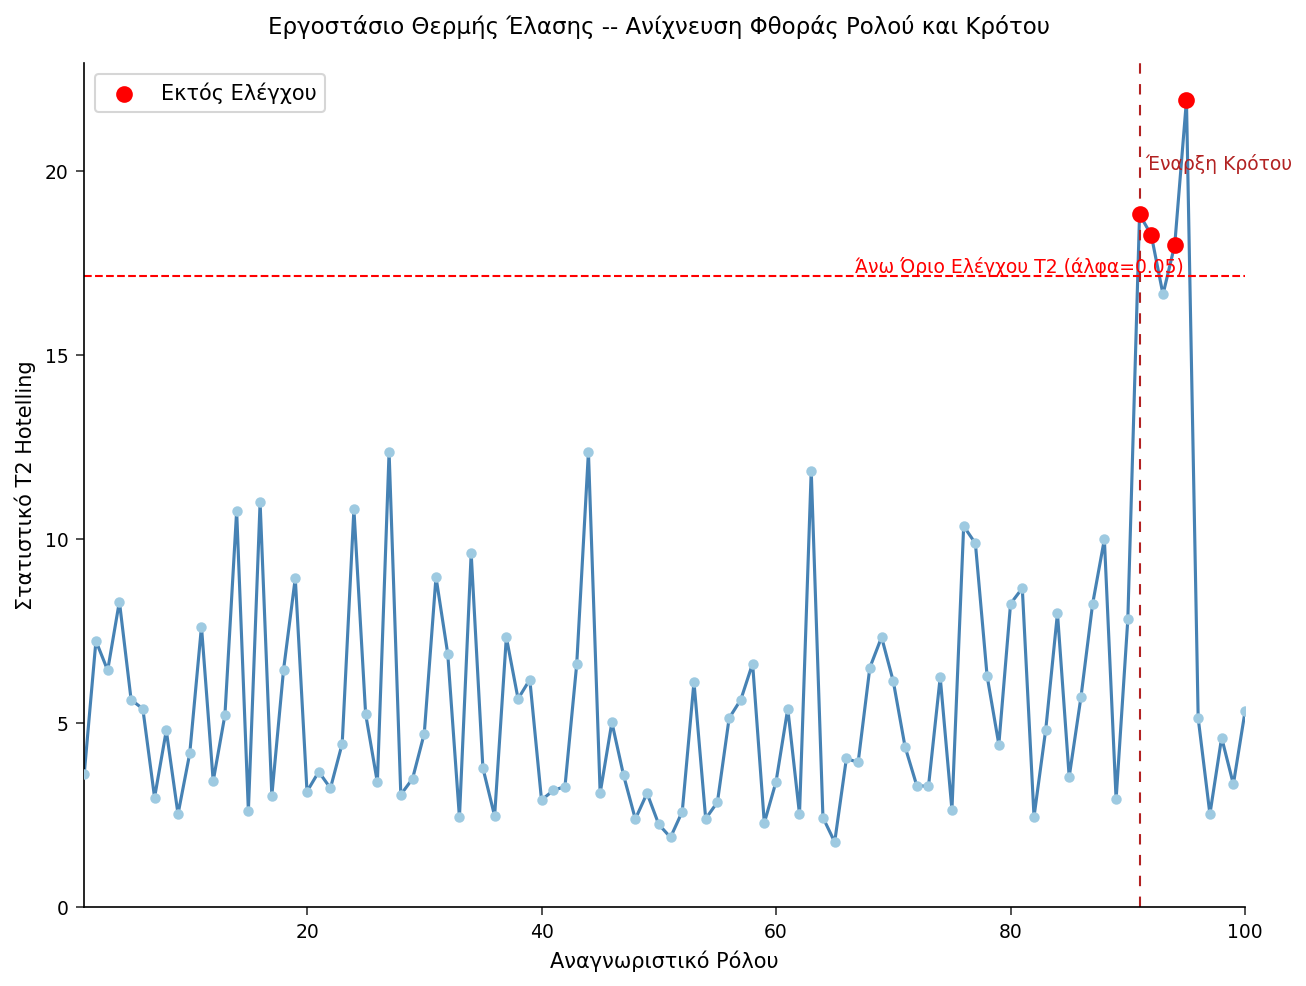

In [4]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel="Εκτός Ελέγχου";
  REFLINE _LIMIT / AXIS=y
          ΕΤΙΚΕΤΑ="Άνω Όριο Ελέγχου T2 (άλφα=0.05)"
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ΕΤΙΚΕΤΑ="Έναρξη Κρότου"
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ΕΤΙΚΕΤΑ="Αναγνωριστικό Ρόλου" MIN=1 MAX=100;
  YAXIS ΕΤΙΚΕΤΑ="Στατιστικό T2 Hotelling" MIN=0;
  TITLE "Εργοστάσιο Θερμής Έλασης -- Ανίχνευση Φθοράς Ρολού και Κρότου";
ΕΚΤΕΛΕΣΗ;


---


### Βήμα 4 &mdash; Ποσοτικοποίηση των ρόλων εκτός ελέγχου

Οι ρόλοι εκτός ελέγχου δρομολογούνται σε ξεχωριστό σύνολο δεδομένων για
το γραφείο ποιότητας. Η `PROC MEANS` αντιπαραβάλλει το επίπεδο *T*&sup2;
των σημασμένων ρόλων με τον πληθυσμό εντός ελέγχου, και οι σημασμένοι
ρόλοι εξάγονται για δρομολόγηση απόρριψης/επανεπεξεργασίας.


In [5]:
ΔΕΔΟΜΕΝΑ mill_ooc;
  ΟΡΙΣΜΟΣ mill_scores;
  ΕΑΝ _SIGNAL = 1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=mill_scores n mean MAX maxdec=2;
  ΚΛΑΣΗ _SIGNAL;
  ΜΕΤΑΒΛΗΤΗ _TSQUARED;
  TITLE 'T2 ανά κατάσταση ελέγχου (0 = εντός ελέγχου, 1 = σήμα)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=mill_ooc noobs label;
  ΜΕΤΑΒΛΗΤΗ coil_id _TSQUARED _LIMIT;
  TITLE 'Ρόλοι εκτός ελέγχου για επιθεώρηση';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


                                 T2 ανά κατάσταση ελέγχου (0 = εντός ελέγχου, 1 = σήμα)                                 

                                                  The MEANS Procedure

                                 Analysis Variable : _TSQUARED Στατιστικό T2

        Σήμα Εκτός Ελέγχου                          N Obs           Mean        Maximum
        -------------------------------------------------------------------------------
        0                                              96           5.39          16.64
        1                                               4          19.24          21.91
        -------------------------------------------------------------------------------

                                           Ρόλοι εκτός ελέγχου για επιθεώρηση                                           

                  Αναγνωριστικό Ρόλου            Στατιστικό T2             Όριο Ελέγχου
                                   91                18.813814                


NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Ευρήματα

- **Ρόλοι υπό παρακολούθηση**: 100· **όριο ελέγχου** *T*&sup2; = **17,13**
  (&alpha; = 0,05).
- **Ρόλοι εκτός ελέγχου**: **4** &mdash; οι ρόλοι **91, 92, 94, 95**,
  όλοι εντός του εισαχθέντος παραθύρου κρότου (91&ndash;95). Ο ρόλος 93
  κορυφώνεται στο *T*&sup2; = 16,64, μόλις κάτω από το όριο.
- **Μέγιστη σοβαρότητα**: *T*&sup2; = **21,91** στον ρόλο 95 (περίπου
  1,3&times; το όριο)· οι ρόλοι εντός ελέγχου έχουν μέσο όρο
  *T*&sup2; &asymp; **5,4**.
- **Φθορά έναντι σφάλματος**: η σταδιακή αύξηση φθοράς κυλίνδρου
  ανεβάζει τη γραμμή αναφοράς των μεταγενέστερων ρόλων αλλά ποτέ δεν
  διασχίζει το όριο από μόνη της, οπότε το ενιαίο πολυμεταβλητό γράφημα
  διακρίνει την αργή μετατόπιση (παρακολούθηση) από το οξύ συμβάν
  κρότου (δράση).
- **Ενέργεια**: οι τέσσερις σημασμένοι ρόλοι εξάγονται στο
  `steel_mill_ooc_coils.csv` για επιθεώρηση και δρομολόγηση
  απόρριψης/επανεπεξεργασίας· η υπογραφή κρότου υποδεικνύει το έδρανο
  του οπίσθιου κυλίνδρου για επιθεώρηση πριν την επόμενη εκστρατεία.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>